|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 3:</h2>|<h1>PagedAttention<h1>|
|<h2>Section:</h2>|<h1>Writing the kernel<h1>|
|<h2>Lecture:</h2>|<h1><b>Occupancy: why a perfect kernel can use a fifth of the GPU<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
# find the repo root, wherever this notebook was opened from
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# A kernel can be perfect and still waste the machine

The last notebook was about bytes: are you asking the memory system for them
efficiently. This one is about **whether anybody is asking at all**.

A GPU is a pile of independent processors called SMs. Work reaches them one
block at a time. Launch fewer blocks than there are SMs and the rest of the
chip sits idle, no matter how good the code inside the block is.

In [2]:
p = torch.cuda.get_device_properties(0)

print(f'{p.name}')
print(f'  SMs                     {p.multi_processor_count}')
print(f'  max threads per SM      {p.max_threads_per_multi_processor}')
print(f'  so, at 256 threads/block, {p.max_threads_per_multi_processor//256} blocks fit on one SM')

NVIDIA GeForce RTX 4080 Laptop GPU
  SMs                     58
  max threads per SM      1536
  so, at 256 threads/block, 6 blocks fit on one SM


### The prediction

Up to `blocks = SMs`, every extra block lands on an empty SM and buys you its
full share of bandwidth. Throughput should rise in a straight line.

After that, the SMs are all busy and extra blocks just queue. The line should
go flat.

A knee, at exactly the SM count. Not a curve, not a gradual roll-off.

In [3]:
sms = p.multi_processor_count
blocks = np.array([1,2,4,8,16,29,58,87,116,232,464,1024,4096])
predicted = np.minimum(blocks/sms, 1.0)          # share of the machine in use

for b,q in zip(blocks[:8], predicted[:8]):
  print(f'{b:5} blocks -> {100*q:5.1f}% of the SMs have work')

    1 blocks ->   1.7% of the SMs have work
    2 blocks ->   3.4% of the SMs have work
    4 blocks ->   6.9% of the SMs have work
    8 blocks ->  13.8% of the SMs have work
   16 blocks ->  27.6% of the SMs have work
   29 blocks ->  50.0% of the SMs have work
   58 blocks -> 100.0% of the SMs have work
   87 blocks -> 100.0% of the SMs have work


# Measure it

In [4]:
KERNEL = r"""
#include <ATen/cuda/CUDAContext.h>
#include <c10/cuda/CUDAException.h>
#include <torch/extension.h>

// A grid-stride loop, so the TOTAL work is the same no matter how many blocks
// you launch. Fewer blocks just means each one walks further. Only how much
// can happen at once changes.
__global__ void grid_stride_read(const float* __restrict__ x,
                                 float* __restrict__ sink, const long n) {
  float acc = 0.f;
  for (long i = blockIdx.x * (long)blockDim.x + threadIdx.x; i < n;
       i += (long)gridDim.x * blockDim.x)
    acc += x[i];
  if (acc == 1e30f) sink[0] = acc;
}

void read_with_blocks(torch::Tensor x, torch::Tensor sink, int64_t blocks) {
  grid_stride_read<<<(int)blocks, 256, 0, at::cuda::getCurrentCUDAStream()>>>(
      x.data_ptr<float>(), sink.data_ptr<float>(), x.numel());
  C10_CUDA_KERNEL_LAUNCH_CHECK();
}
PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) { m.def("read_with_blocks", &read_with_blocks); }
"""

mod = cudalib.build_source('nb_occupancy', KERNEL)

In [5]:
SPAN = 256 * 1024 * 1024
x    = torch.randn(SPAN//4, device='cuda')
sink = torch.zeros(1, device='cuda')

peak = cudalib.peak_bandwidth(fresh=True)
print(f'peak bandwidth, measured just now: {peak:.0f} GB/s')

peak bandwidth, measured just now: 295 GB/s


In [6]:
measured = []
for b in blocks:
  ms = cudalib.bench_ms(lambda: mod.read_with_blocks(x,sink,int(b)), iters=20, best_of=2)
  measured.append(SPAN/(ms*1e-3)/1e9)

for b,g in zip(blocks, measured):
  print(f'{b:5} blocks  ({b/sms:5.2f} per SM)  {g:6.0f} GB/s')

    1 blocks  ( 0.02 per SM)      14 GB/s
    2 blocks  ( 0.03 per SM)      28 GB/s
    4 blocks  ( 0.07 per SM)      55 GB/s
    8 blocks  ( 0.14 per SM)     113 GB/s
   16 blocks  ( 0.28 per SM)     210 GB/s
   29 blocks  ( 0.50 per SM)     333 GB/s
   58 blocks  ( 1.00 per SM)     412 GB/s
   87 blocks  ( 1.50 per SM)     420 GB/s
  116 blocks  ( 2.00 per SM)     421 GB/s
  232 blocks  ( 4.00 per SM)     422 GB/s
  464 blocks  ( 8.00 per SM)     421 GB/s
 1024 blocks  (17.66 per SM)     422 GB/s
 4096 blocks  (70.62 per SM)     422 GB/s


# The knee

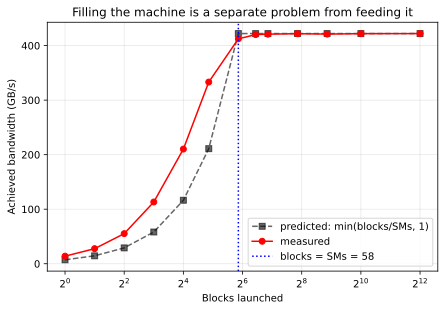

In [7]:
m = np.array(measured)

plt.figure(figsize=(7,4.5))
plt.plot(blocks, predicted*m.max(), 'ks--', alpha=.6, label='predicted: min(blocks/SMs, 1)')
plt.plot(blocks, m, 'ro-', label='measured')
plt.axvline(sms, color='b', ls=':', label=f'blocks = SMs = {sms}')
plt.xscale('log', base=2)
plt.xlabel('Blocks launched')
plt.ylabel('Achieved bandwidth (GB/s)')
plt.title('Filling the machine is a separate problem from feeding it')
plt.legend()
plt.grid(alpha=.3)
plt.show()

In [8]:
knee = blocks[np.argmax(m > .95*m.max())]
print(f'measured knee:  {knee} blocks')
print(f'SM count:       {sms}')
print(f'\nat 1 block:   {m[0]:6.0f} GB/s  ({100*m[0]/m.max():.1f}% of what this kernel can do)')
print(f'at the knee:  {m.max():6.0f} GB/s')

measured knee:  58 blocks
SM count:       58

at 1 block:       14 GB/s  (3.3% of what this kernel can do)
at the knee:     422 GB/s


### Why this is the whole argument for split-K

A decode attention kernel gives one block to each `(sequence, head)` pair. So
the grid is `num_seqs x num_heads`, and at batch 1 that is:

In [9]:
for num_seqs in [1,2,4,8,16,64]:
  grid = num_seqs * 16                       # 16 query heads
  print(f'{num_seqs:3} sequences -> {grid:5} blocks  '
        f'({100*min(grid/sms,1):5.1f}% of the SMs)')

  1 sequences ->    16 blocks  ( 27.6% of the SMs)
  2 sequences ->    32 blocks  ( 55.2% of the SMs)
  4 sequences ->    64 blocks  (100.0% of the SMs)
  8 sequences ->   128 blocks  (100.0% of the SMs)
 16 sequences ->   256 blocks  (100.0% of the SMs)
 64 sequences ->  1024 blocks  (100.0% of the SMs)


At one sequence the kernel gets a fifth of the machine, and there is nothing
you can do about it inside the block. The fix has to change the **grid**.

Stage 08c cuts the context into chunks so that each chunk gets its own block,
and merges the partial softmax states afterwards. Batch 1 is also the case
every interactive request lives in, so this is not a corner.

    ./vc guide 8c